# Benchmark EDA plots

This notebook replaces the four earlier graph notebooks. Shared loading, cleaning, and plotting helpers are defined once, then reused for each benchmark dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("..") / "data" / "graphs"
NUMERIC_COLS = ["QED", "SA", "MW", "LogP"]
BINARY_COLS = ["Lipinski", "BRENK", "PAINS", "Glaxo"]
STATUS_PALETTE = {
    "bad": "#F4A7A7",
    "good": "#A8E6A3",
    "ambiguous": "#A7C7E7",
}


## Shared helpers

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns={"logP": "LogP"}).copy()


def clean_numeric_columns(df: pd.DataFrame, numeric_cols=NUMERIC_COLS) -> pd.DataFrame:
    df = df.copy()
    for col in numeric_cols:
        if col not in df.columns:
            continue
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def clean_binary_columns(df: pd.DataFrame, binary_cols=BINARY_COLS) -> pd.DataFrame:
    df = df.copy()
    truthy = {"true", "1", "yes", "y", "t"}
    falsy = {"false", "0", "no", "n", "f"}
    for col in binary_cols:
        if col not in df.columns:
            continue
        values = df[col].astype(str).str.strip().str.lower()
        df[col] = values.map(lambda value: True if value in truthy else False if value in falsy else pd.NA)
    return df


def load_benchmark_csv(file_name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / file_name)
    df = normalize_columns(df)
    df = clean_numeric_columns(df)
    df = clean_binary_columns(df)
    return df


def available_columns(df: pd.DataFrame, columns) -> list[str]:
    return [col for col in columns if col in df.columns]


In [3]:
def plot_numeric_boxplots(
    df: pd.DataFrame,
    category_col: str,
    numeric_cols=NUMERIC_COLS,
    order=None,
    palette=None,
    title: str | None = None,
):
    cols = available_columns(df, numeric_cols)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for index, col in enumerate(cols):
        sns.boxplot(
            data=df,
            x=category_col,
            y=col,
            hue=category_col,
            order=order,
            palette=palette,
            legend=False,
            ax=axes[index],
        )
        axes[index].set_title(f"{col} by {category_col}")
        axes[index].tick_params(axis="x", rotation=30)

    for index in range(len(cols), len(axes)):
        axes[index].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_numeric_kdes(
    df: pd.DataFrame,
    numeric_cols=NUMERIC_COLS,
    category_col: str | None = None,
    categories=None,
    palette=None,
    title: str | None = None,
):
    plot_df = df.copy()
    if category_col and categories:
        plot_df = plot_df[plot_df[category_col].isin(categories)]

    cols = available_columns(plot_df, numeric_cols)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for index, col in enumerate(cols):
        sns.kdeplot(
            data=plot_df,
            x=col,
            hue=category_col,
            hue_order=categories,
            palette=palette,
            fill=True,
            common_norm=False,
            ax=axes[index],
        )
        axes[index].set_title(f"{col} density")

    for index in range(len(cols), len(axes)):
        axes[index].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_binary_feature_share(
    df: pd.DataFrame,
    category_col: str,
    binary_cols=BINARY_COLS,
    order=None,
    palette=None,
    title: str | None = None,
):
    cols = available_columns(df, binary_cols)
    summary = df.groupby(category_col, dropna=False)[cols].mean().reset_index()
    long_summary = summary.melt(id_vars=category_col, var_name="Feature", value_name="Share")

    fig = plt.figure(figsize=(10, 6))
    sns.barplot(
        data=long_summary,
        x="Feature",
        y="Share",
        hue=category_col,
        hue_order=order,
        palette=palette,
    )
    plt.ylim(0, 1)
    plt.ylabel("Share of molecules")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_category_counts(
    df: pd.DataFrame,
    category_col: str,
    order=None,
    palette=None,
    title: str | None = None,
):
    fig = plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=category_col,
        hue=category_col,
        order=order,
        palette=palette,
        legend=False,
    )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Molecule count")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Dataset configuration

In [4]:
DATASETS = {
    "absolute_score": {
        "file": "absolute_score.csv",
        "category_col": "Status",
        "palette": STATUS_PALETTE,
        "comparisons": [
            {
                "name": "Status reason",
                "category_col": "Status_Reason",
                "order": [
                    "bad extreme",
                    "bad medchem",
                    "nature toxin",
                    "good",
                    "side effects",
                    "addiction",
                    "antitumor",
                ],
                "palette": {
                    "bad extreme": "#F4A7A7",
                    "bad medchem": "#F4A7A7",
                    "nature toxin": "#F4A7A7",
                    "good": "#A8E6A3",
                    "side effects": "#A7C7E7",
                    "addiction": "#A7C7E7",
                    "antitumor": "#A7C7E7",
                },
            }
        ],
    },
    "pair_smiles": {
        "file": "pair_smiles.csv",
        "category_col": None,
    },
    "pair_stability": {
        "file": "pair_stability.csv",
        "category_col": "More stable molecule",
        "comparisons": [
            {
                "name": "Stability",
                "category_col": "More stable molecule",
                "order": ["less stable bro", "more stable bro"],
                "palette": {"less stable bro": "#F4A7A7", "more stable bro": "#A8E6A3"},
            }
        ],
    },
    "pair_structure": {
        "file": "pair_structure.csv",
        "category_col": "Status",
        "comparisons": [
            {
                "name": "Quality groups",
                "category_col": "Status",
                "order": ["very bad bro", "bad bro", "good bro"],
                "palette": {"very bad bro": "#F4A7A7", "bad bro": "#FFD37A", "good bro": "#A8E6A3"},
            },
            {
                "name": "Activity",
                "category_col": "Status",
                "order": ["more active bro", "less active bro"],
                "palette": {"more active bro": "#A8E6A3", "less active bro": "#FFD37A"},
            },
            {
                "name": "Metabolism",
                "category_col": "Status",
                "order": ["pro-drug", "active metabolite"],
                "palette": {"pro-drug": "#A7C7E7", "active metabolite": "#D7B5F5"},
            },
        ],
    },
}

loaded_data = {name: load_benchmark_csv(config["file"]) for name, config in DATASETS.items()}
{name: df.shape for name, df in loaded_data.items()}


{'absolute_score': (299, 18),
 'pair_smiles': (48, 15),
 'pair_stability': (97, 19),
 'pair_structure': (99, 17)}

## Overview plots

absolute_score: 299 rows, 18 columns


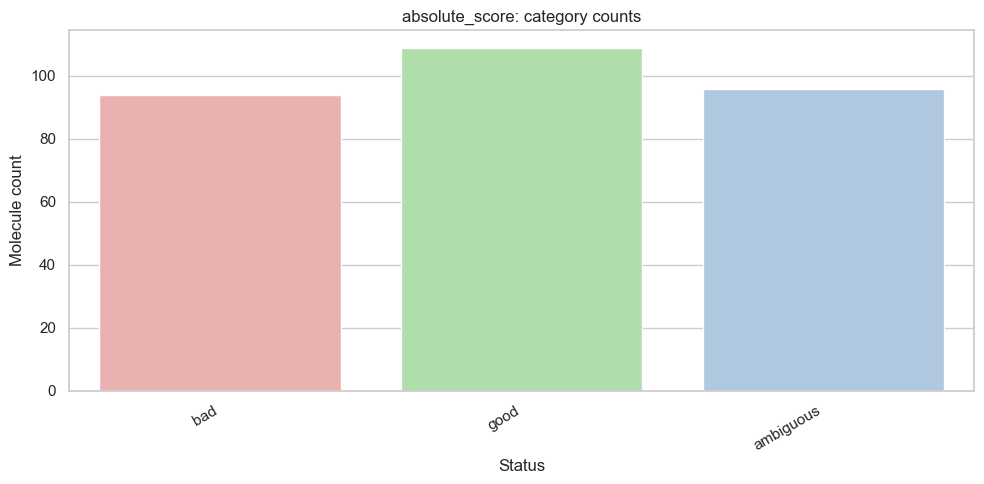

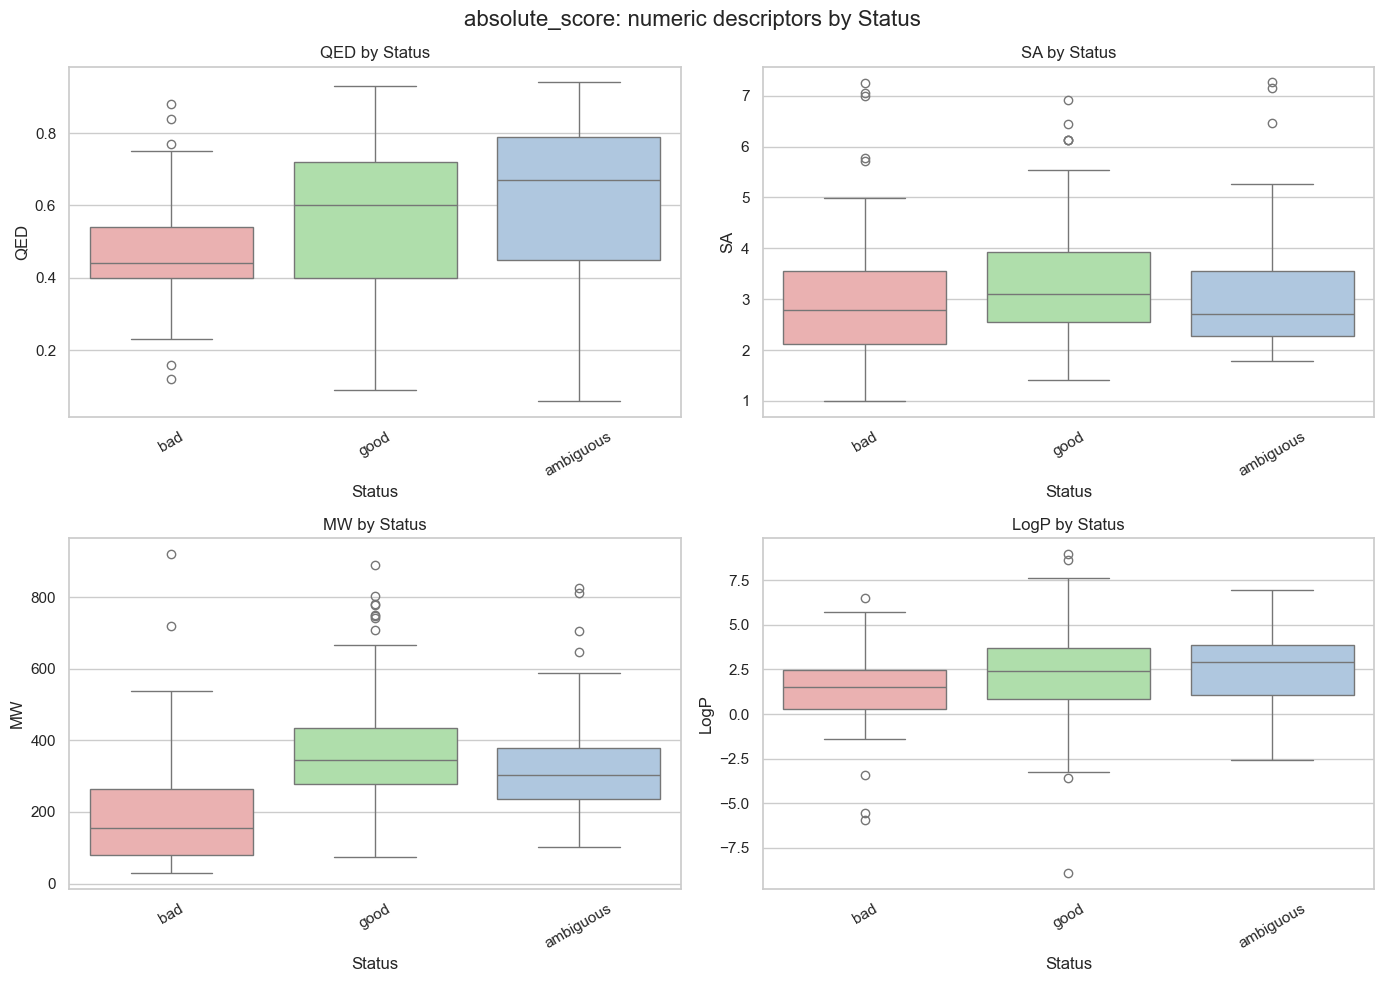

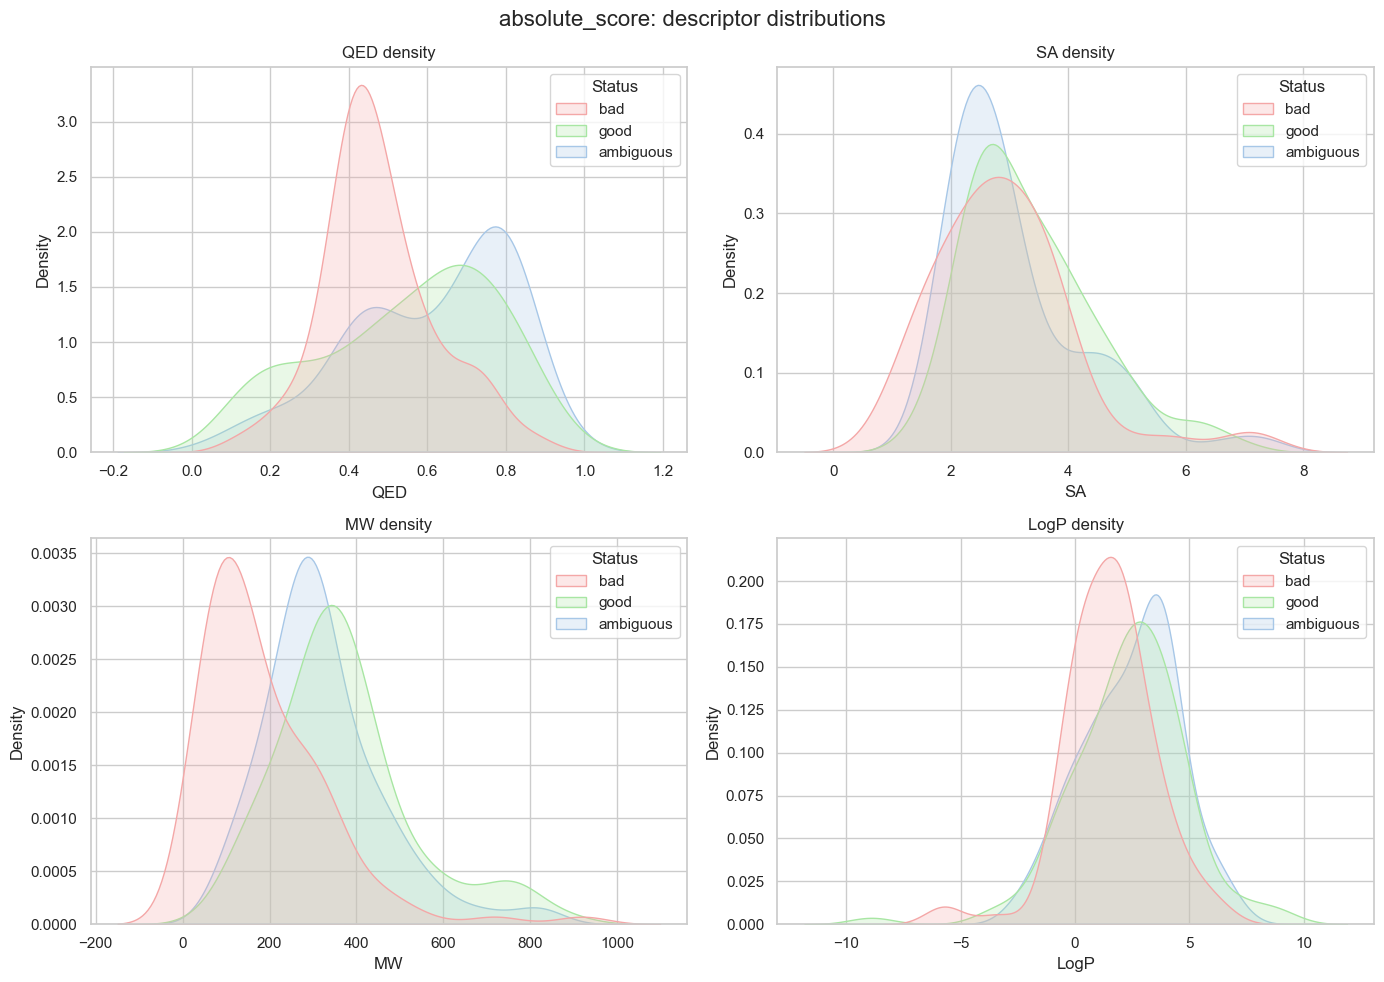

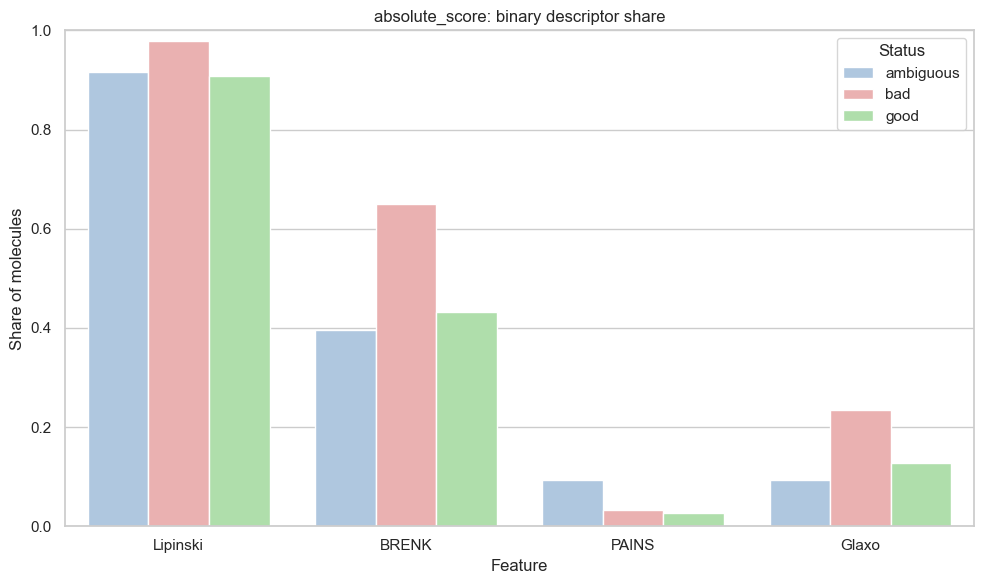

pair_smiles: 48 rows, 15 columns


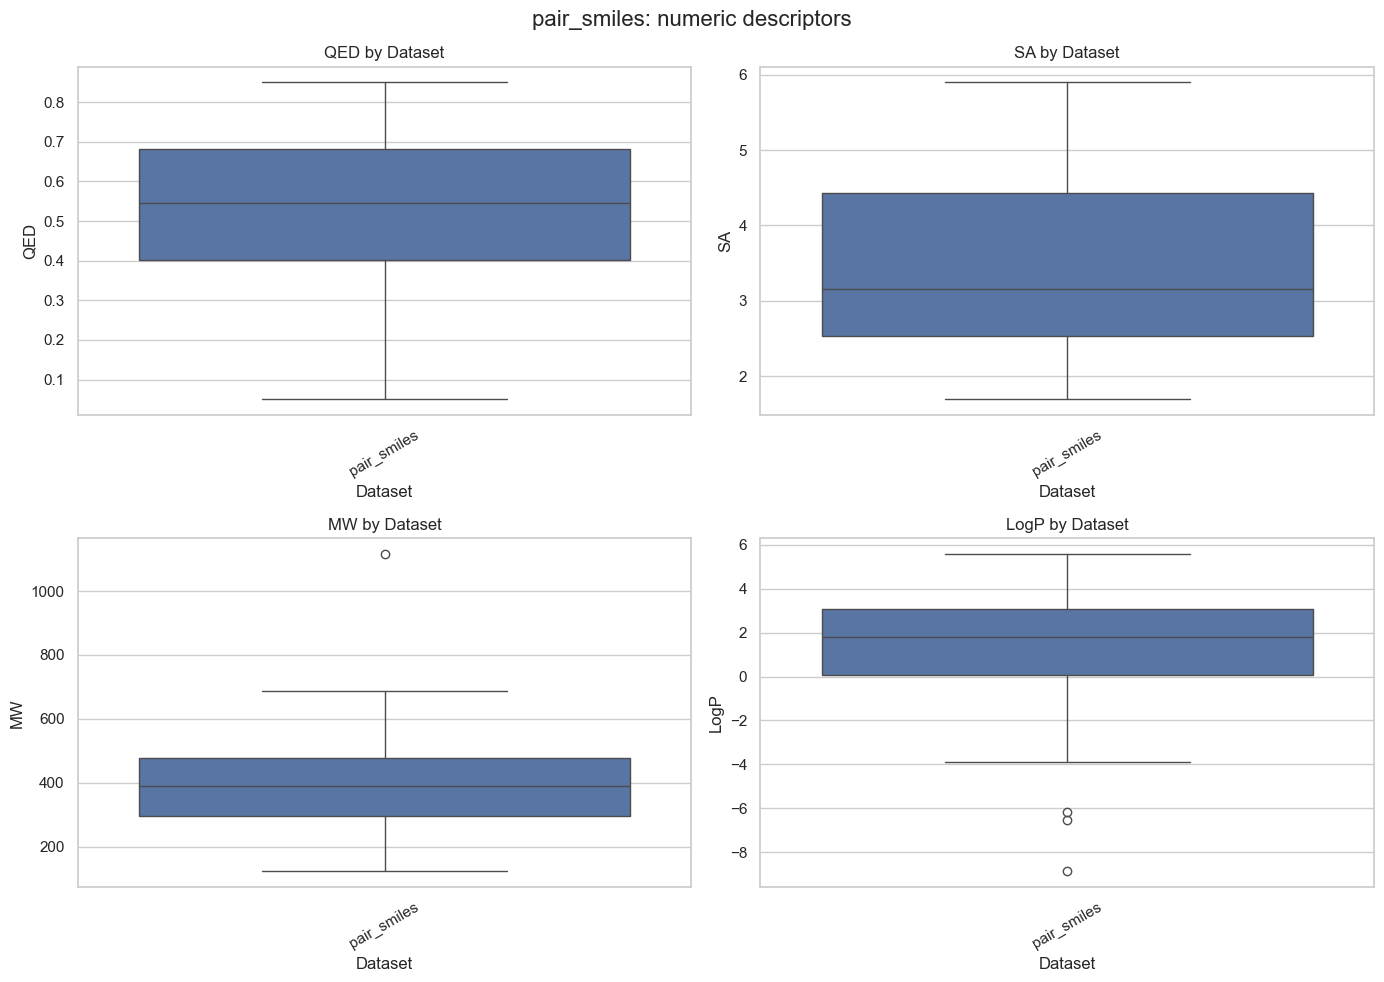

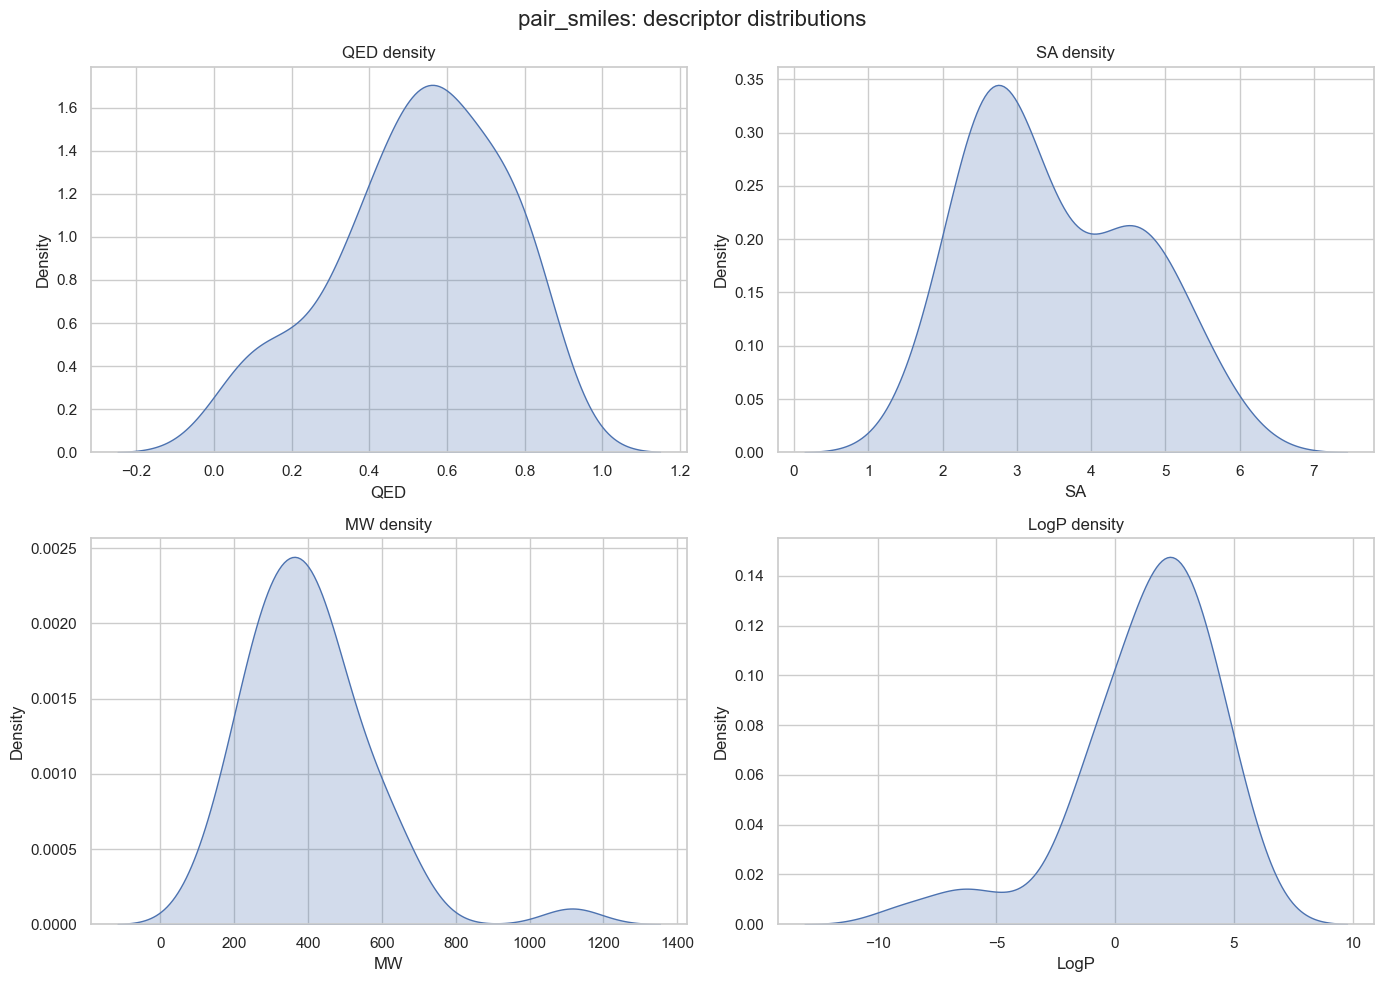

pair_stability: 97 rows, 19 columns


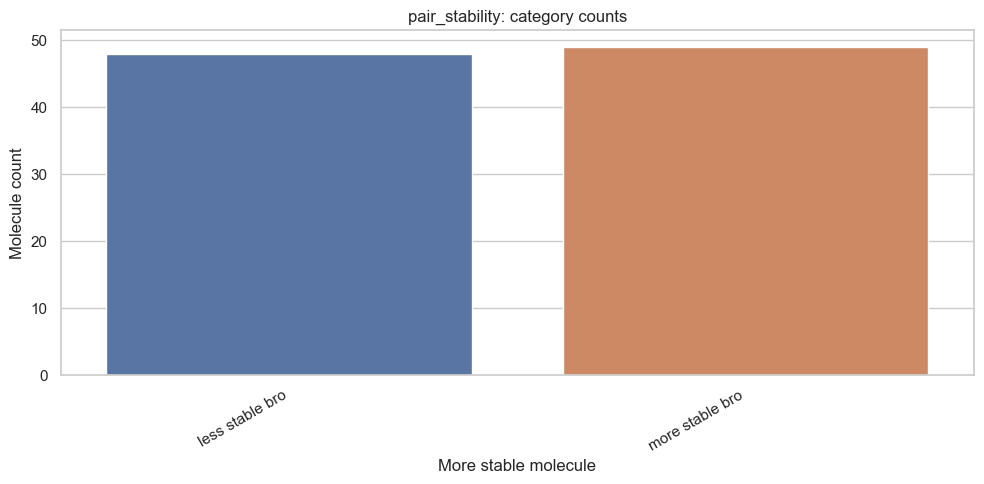

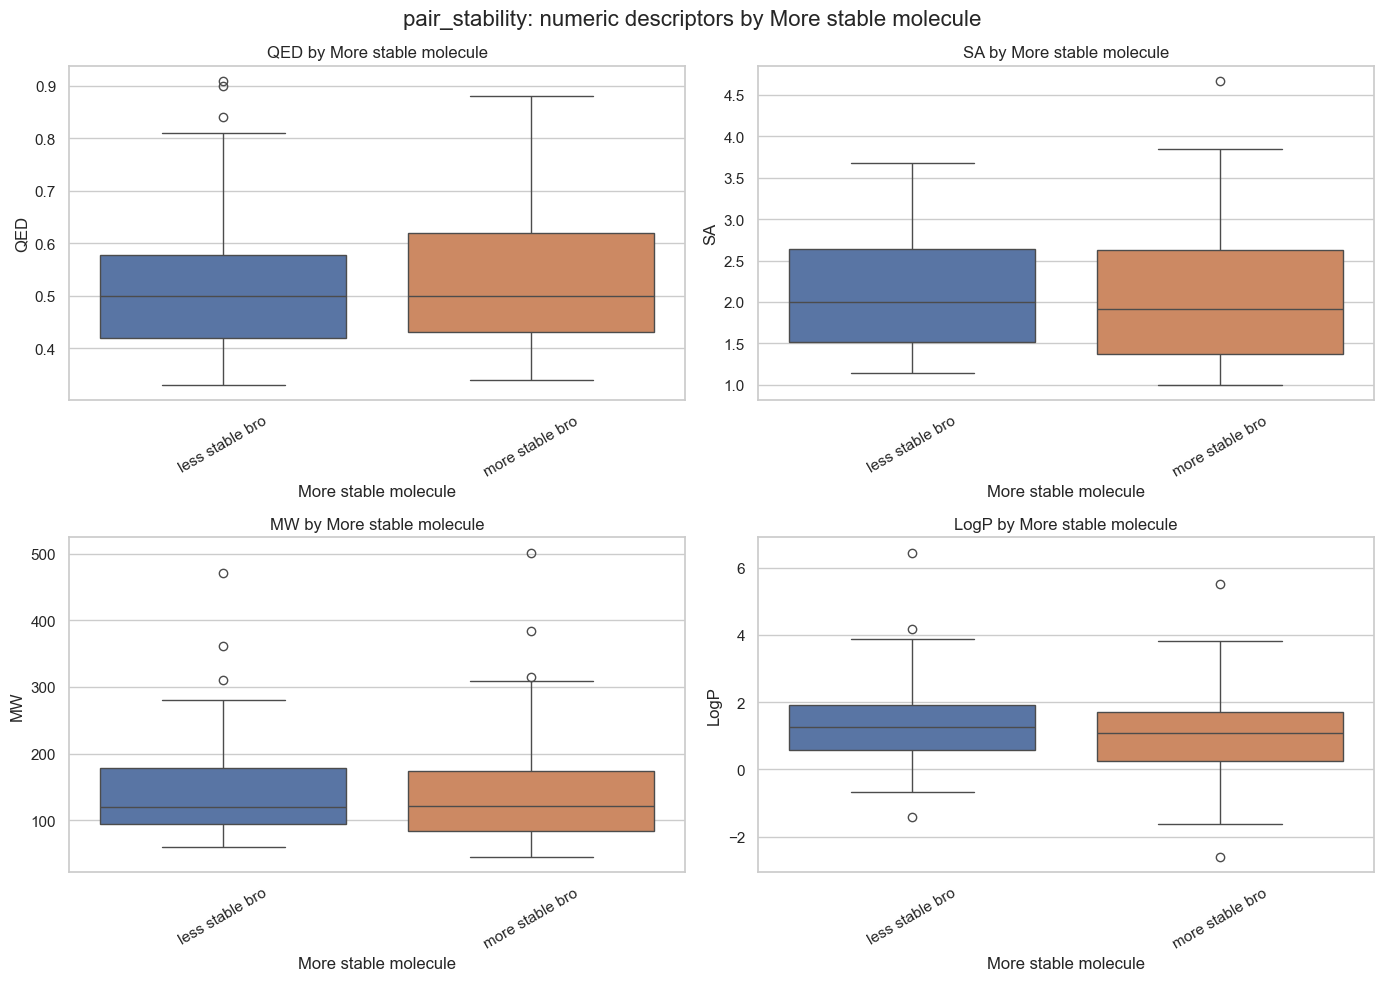

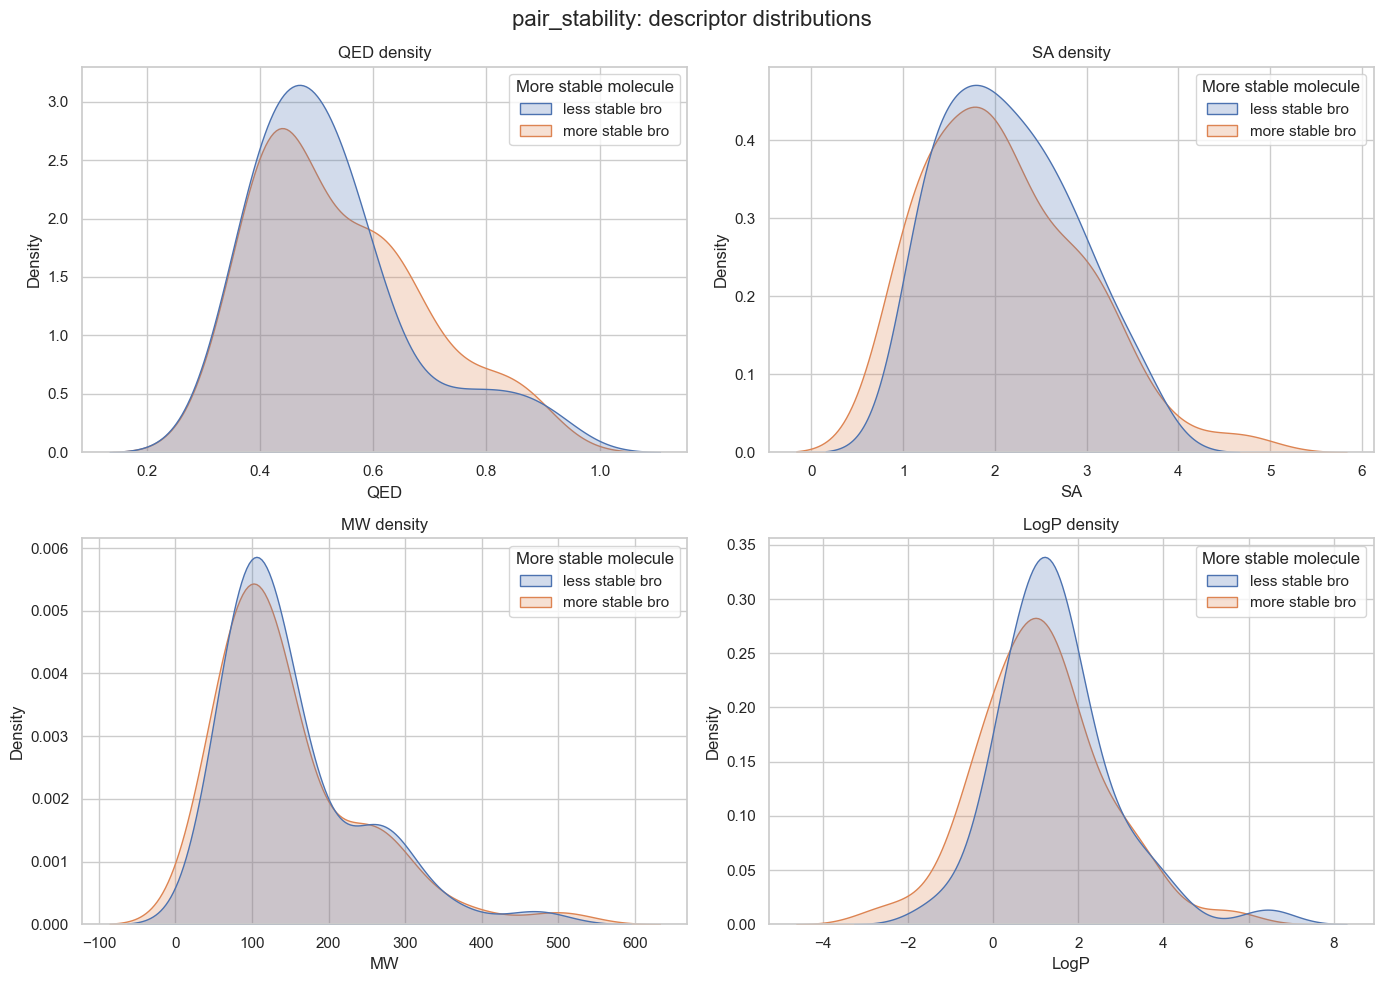

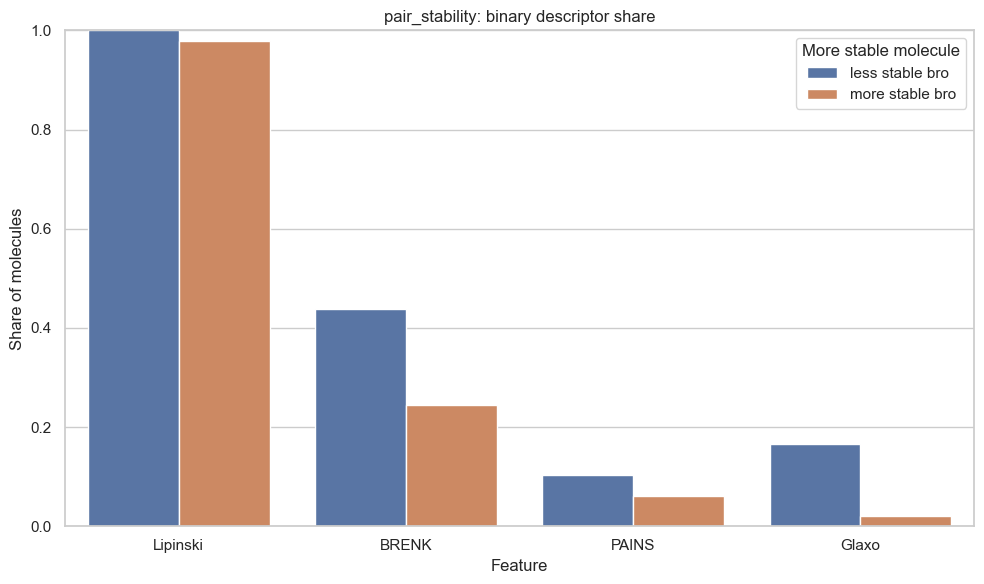

pair_structure: 99 rows, 17 columns


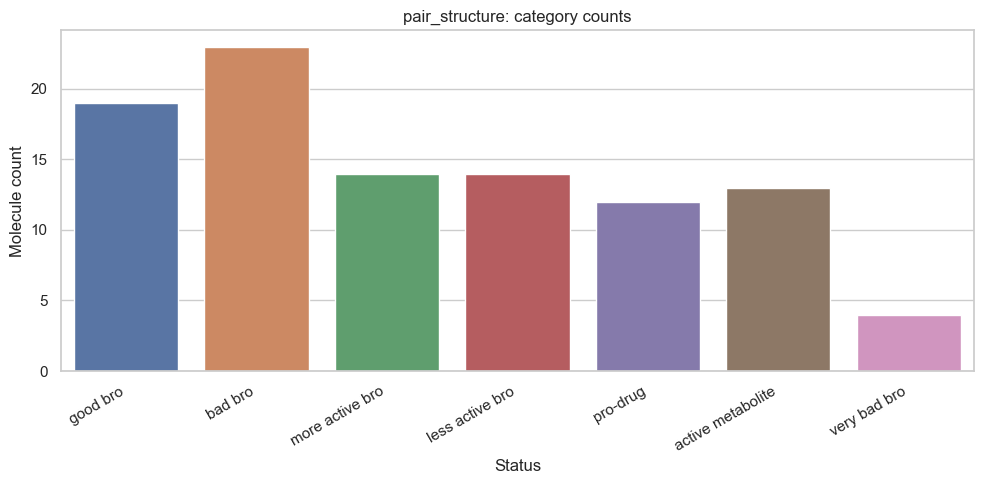

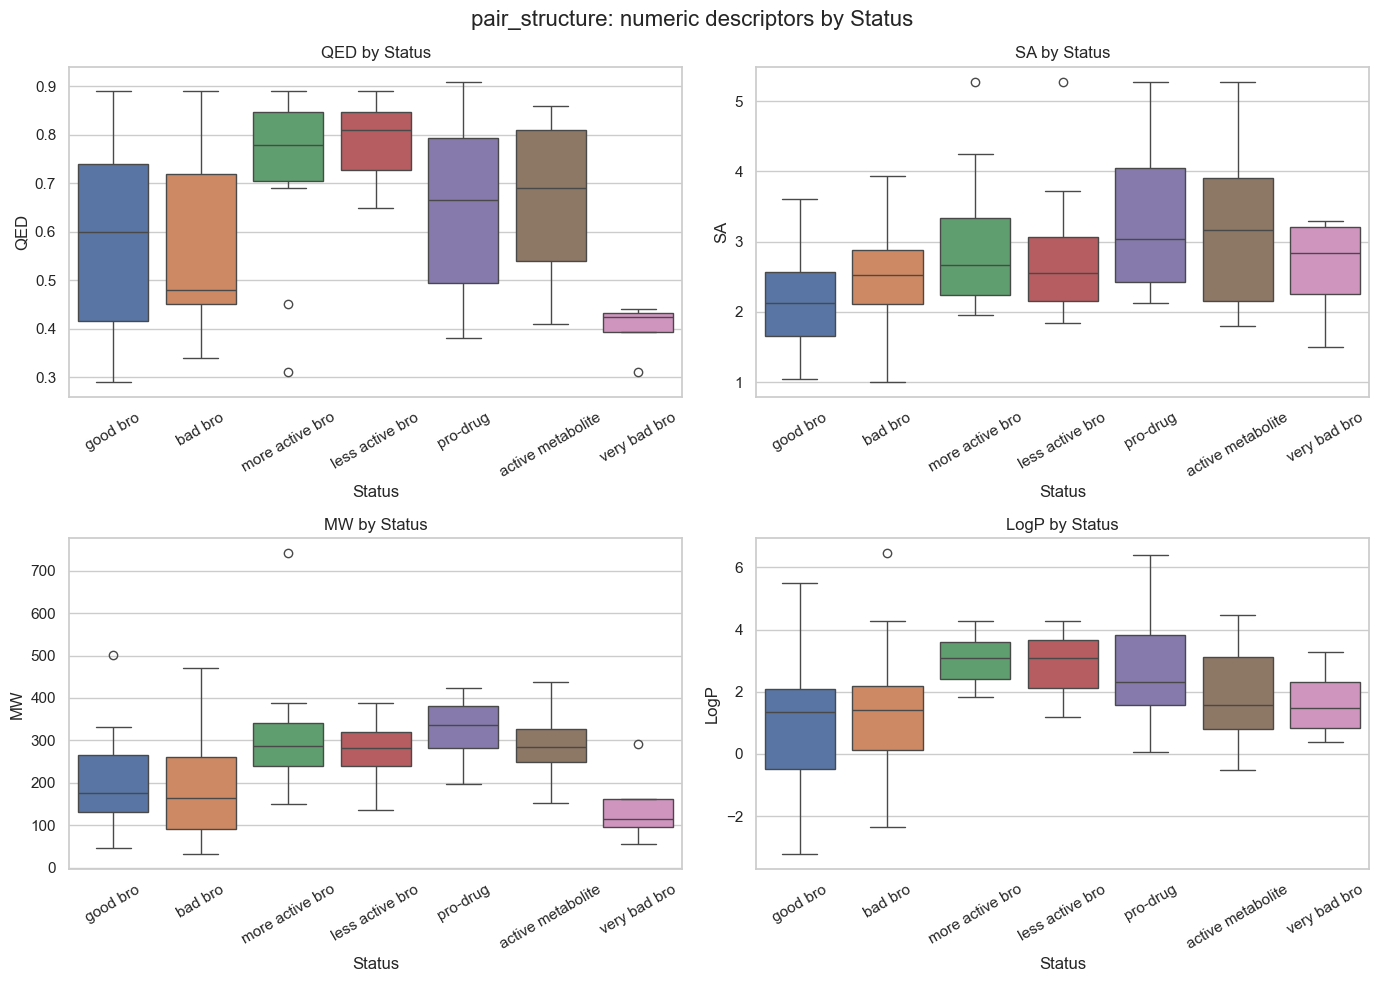

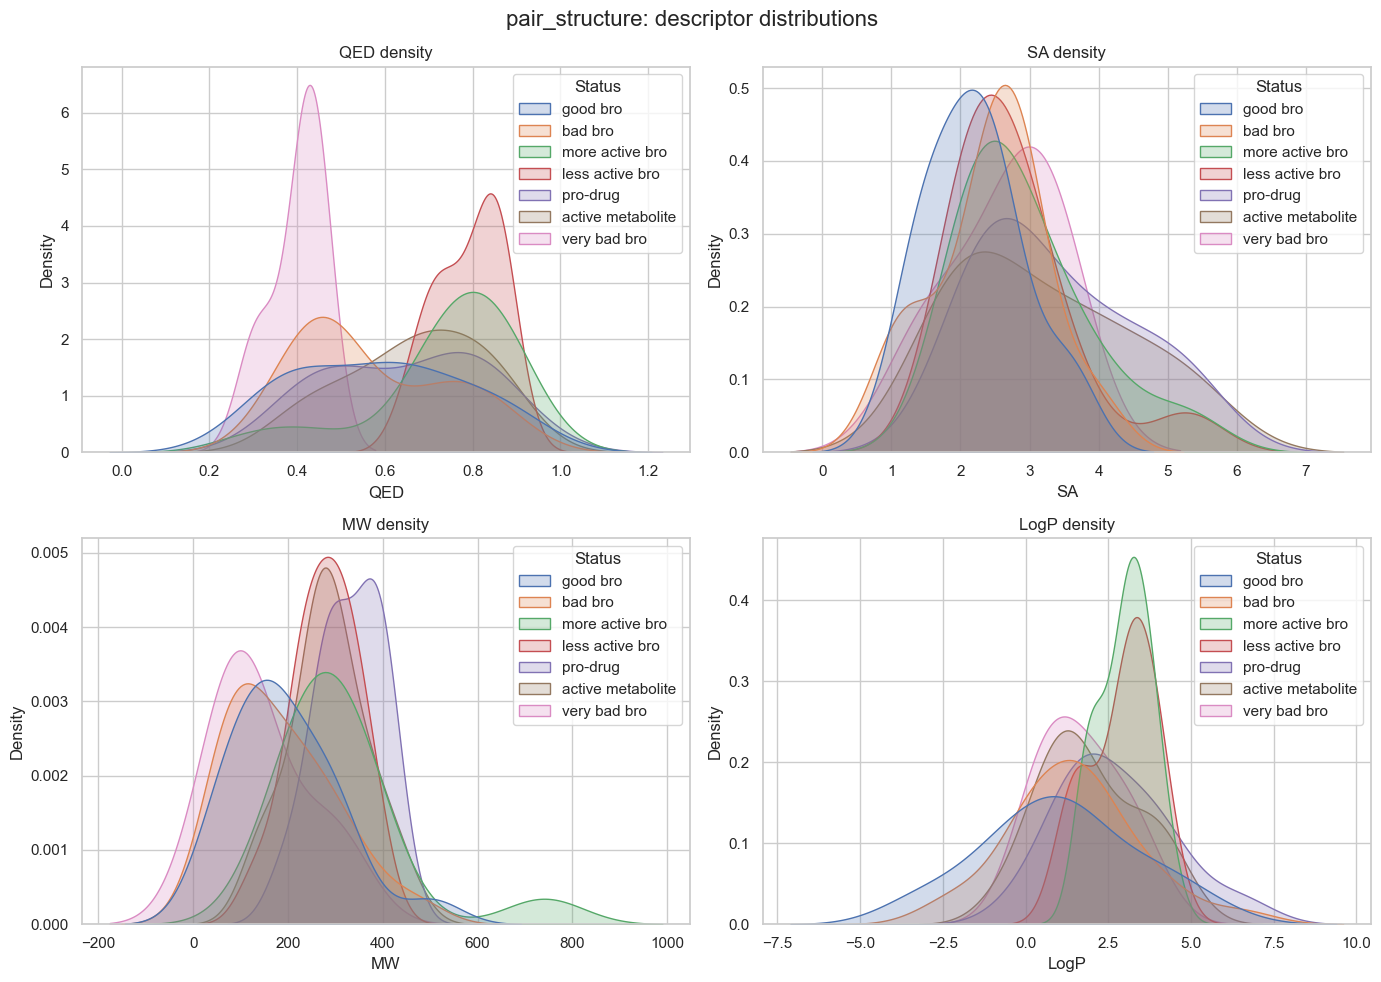

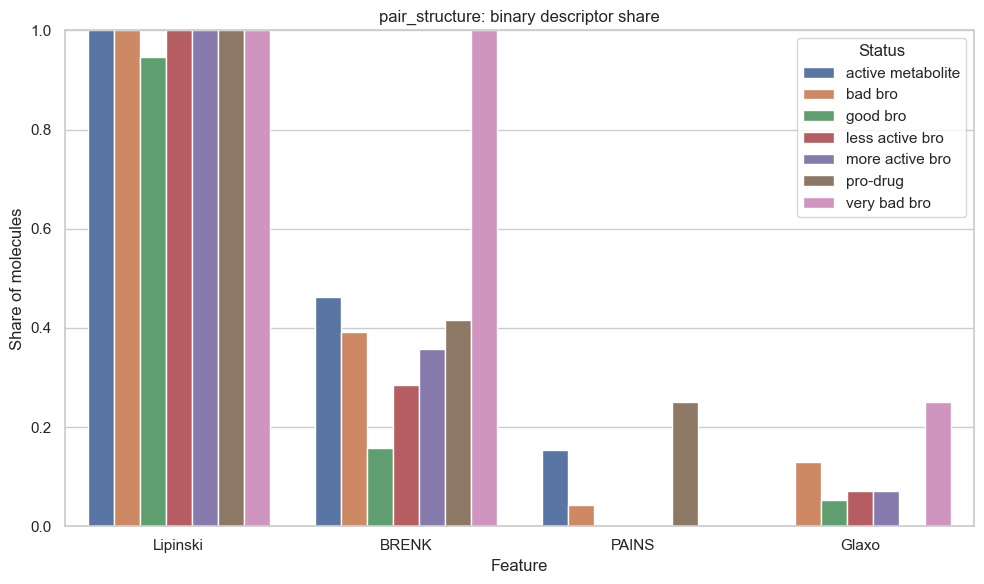

In [5]:
for dataset_name, config in DATASETS.items():
    df = loaded_data[dataset_name]
    category_col = config.get("category_col")
    print(f"{dataset_name}: {df.shape[0]} rows, {df.shape[1]} columns")

    if category_col and category_col in df.columns:
        plot_category_counts(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: category counts",
        )
        plot_numeric_boxplots(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: numeric descriptors by {category_col}",
        )
        plot_numeric_kdes(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: descriptor distributions",
        )
        plot_binary_feature_share(
            df,
            category_col=category_col,
            palette=config.get("palette"),
            title=f"{dataset_name}: binary descriptor share",
        )
    else:
        plot_numeric_boxplots(df.assign(Dataset=dataset_name), category_col="Dataset", title=f"{dataset_name}: numeric descriptors")
        plot_numeric_kdes(df, title=f"{dataset_name}: descriptor distributions")


## Comparison plots

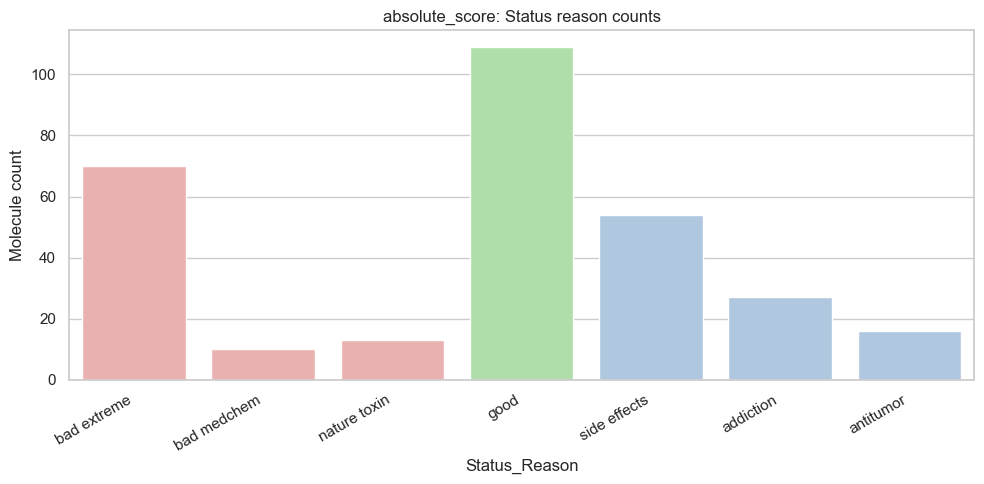

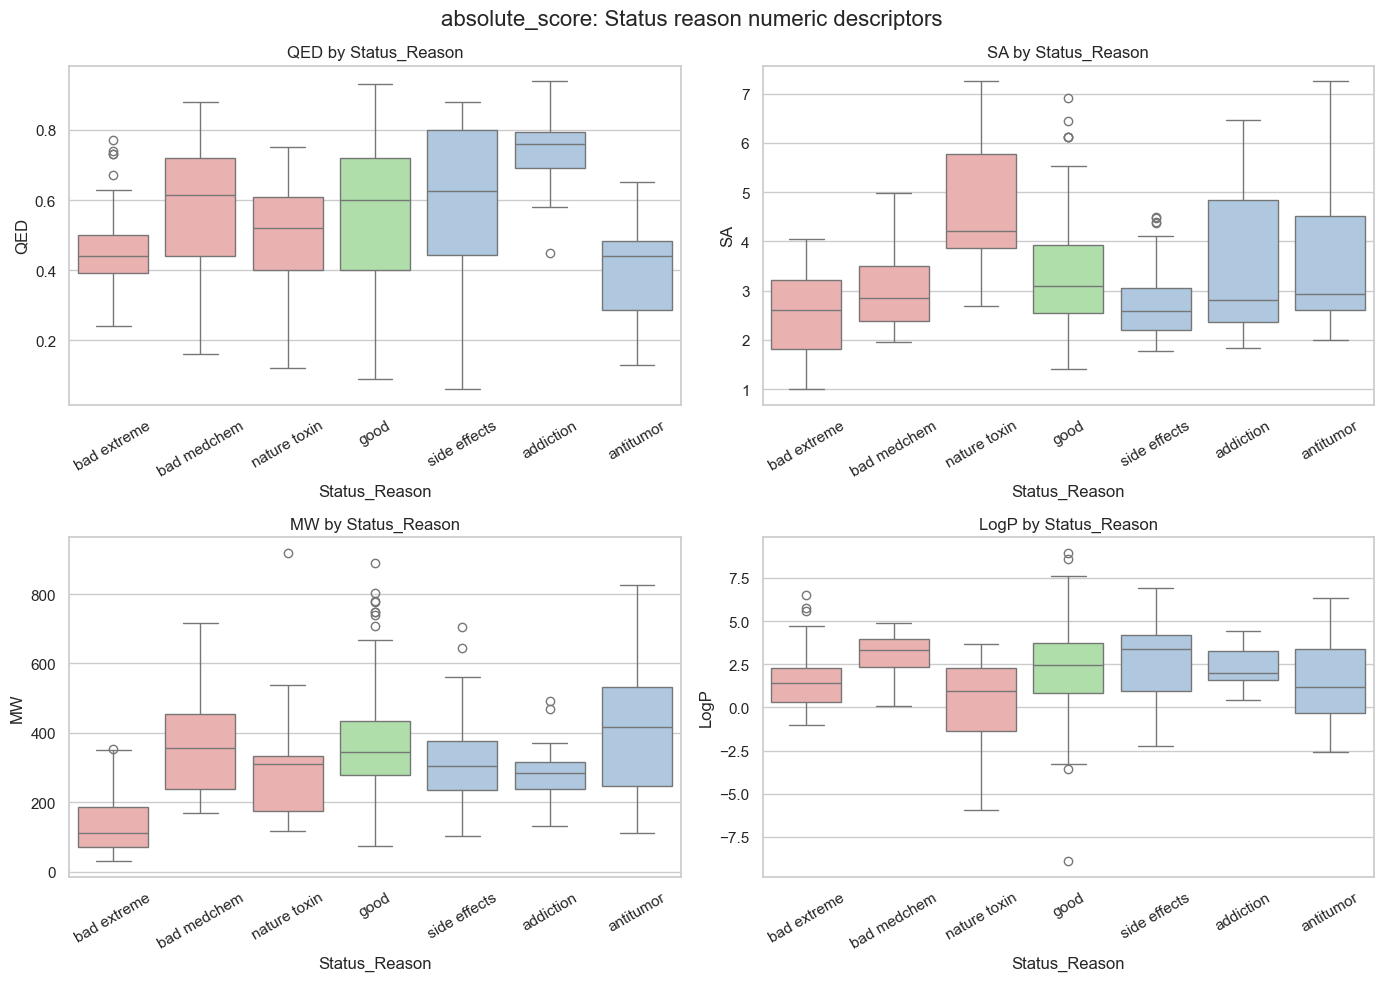

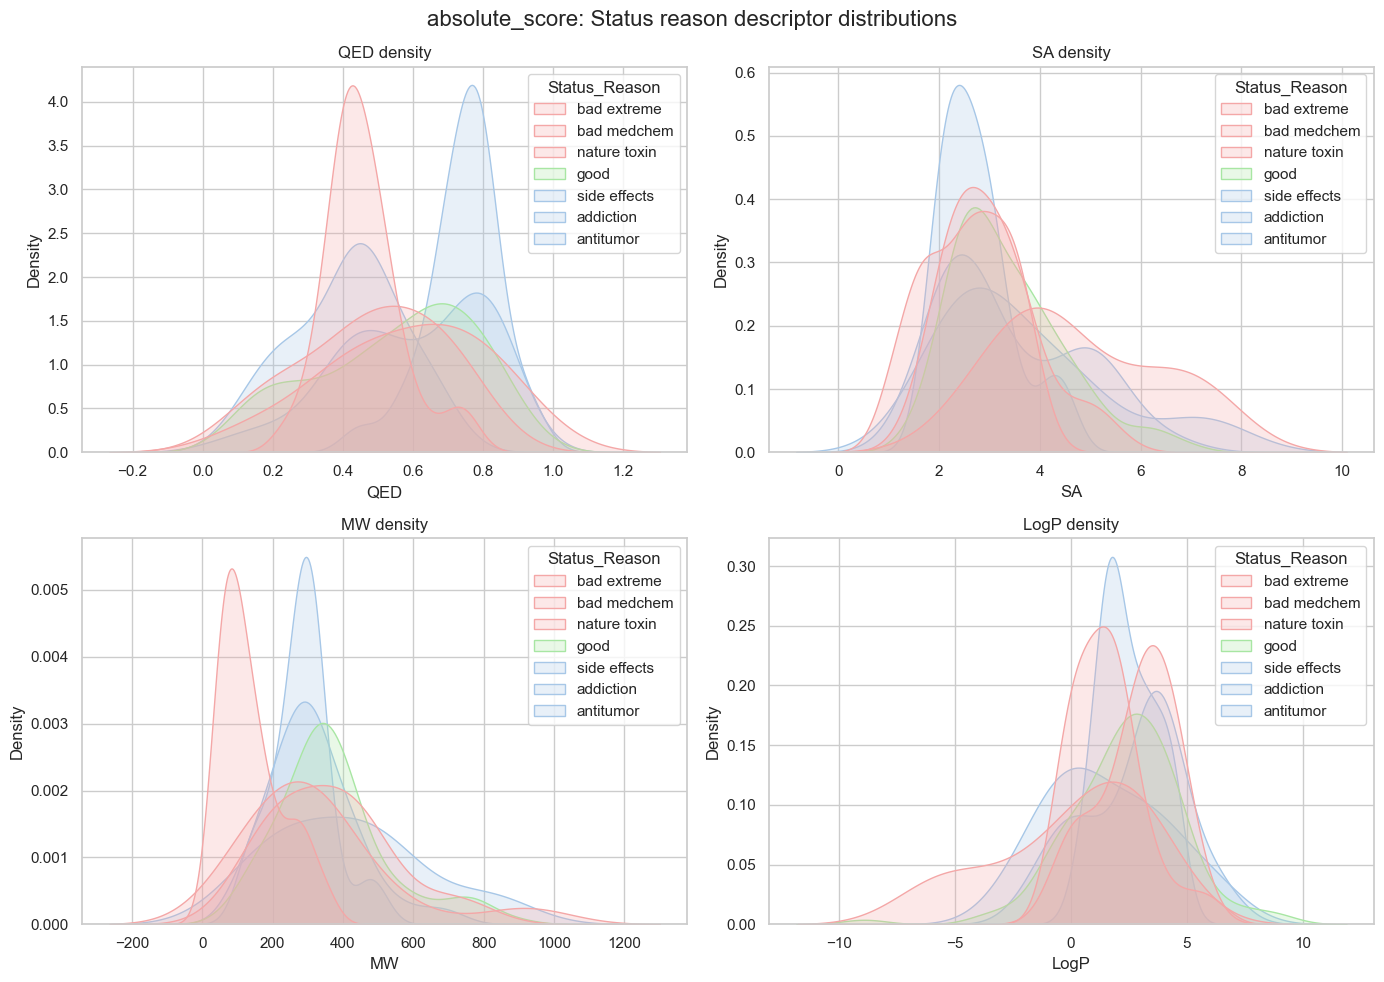

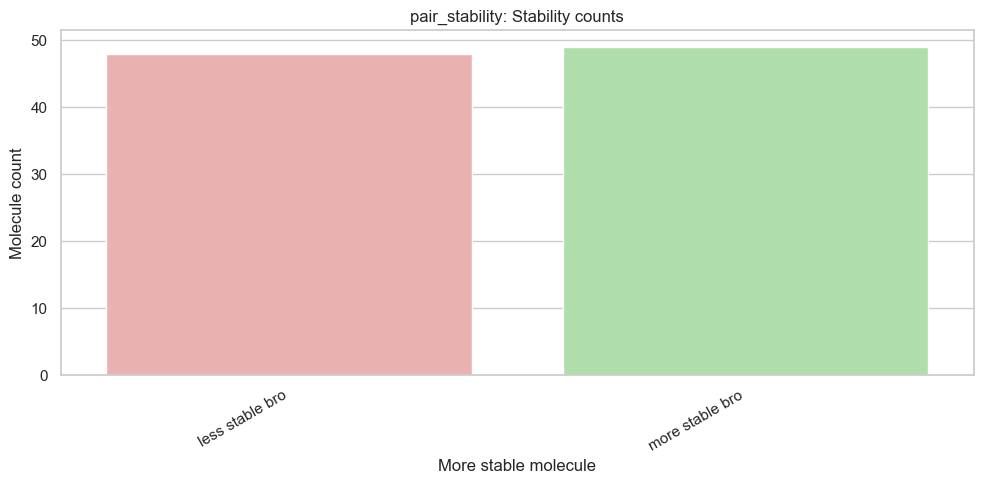

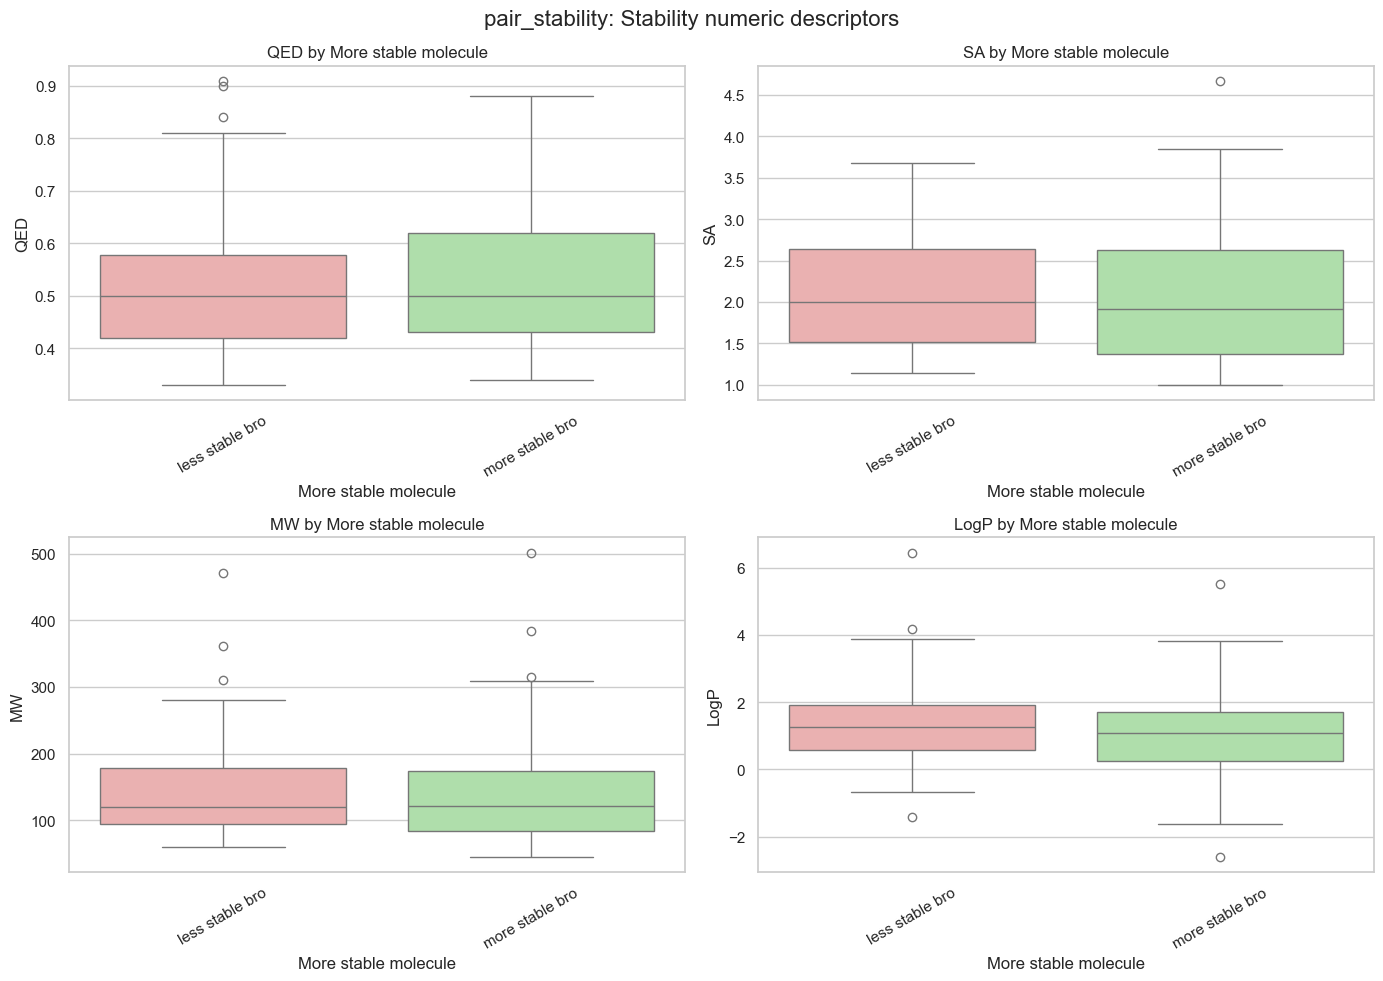

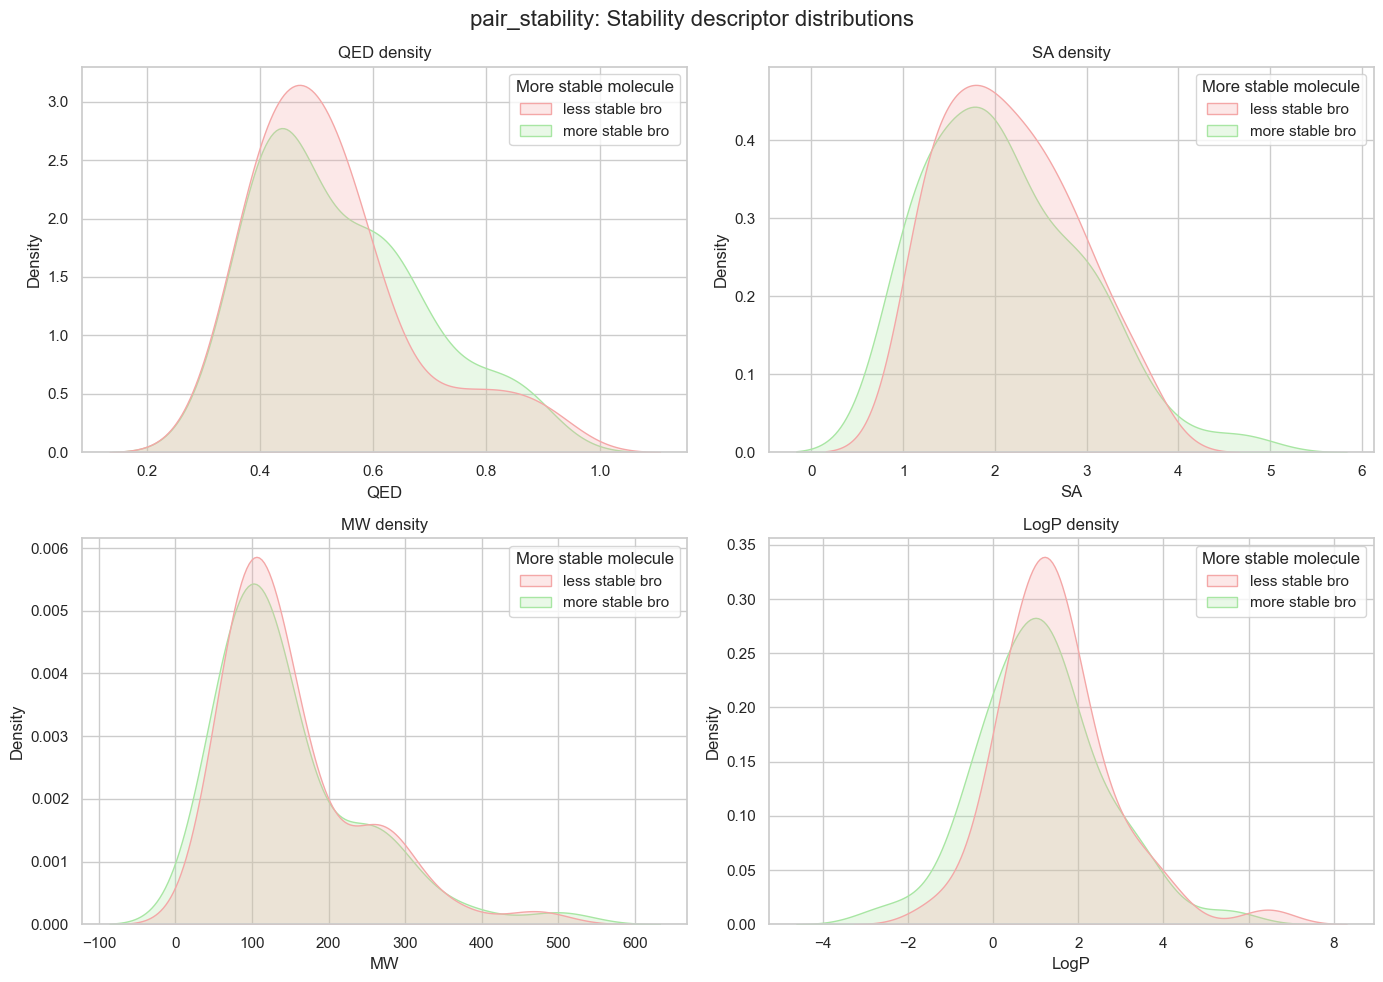

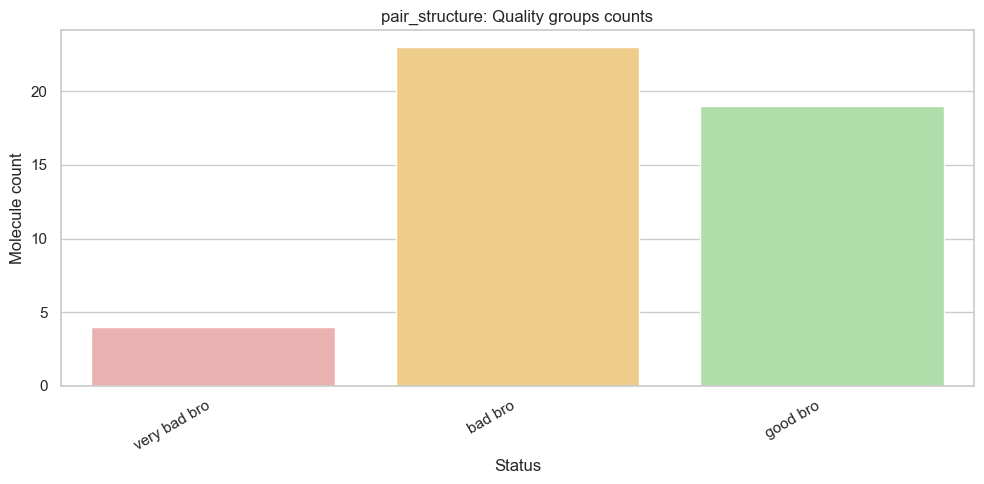

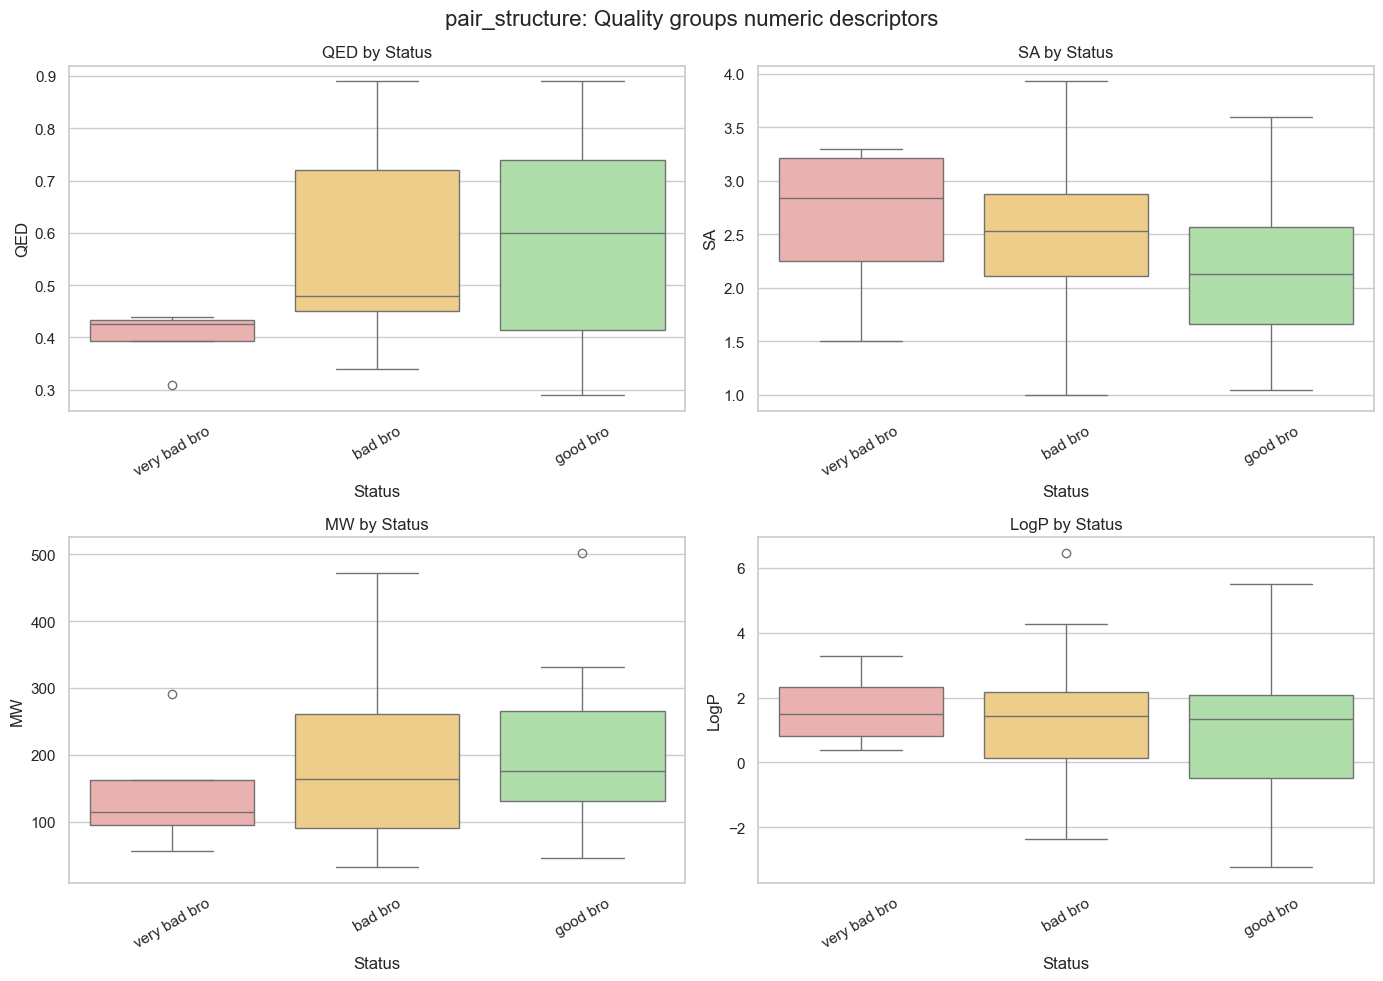

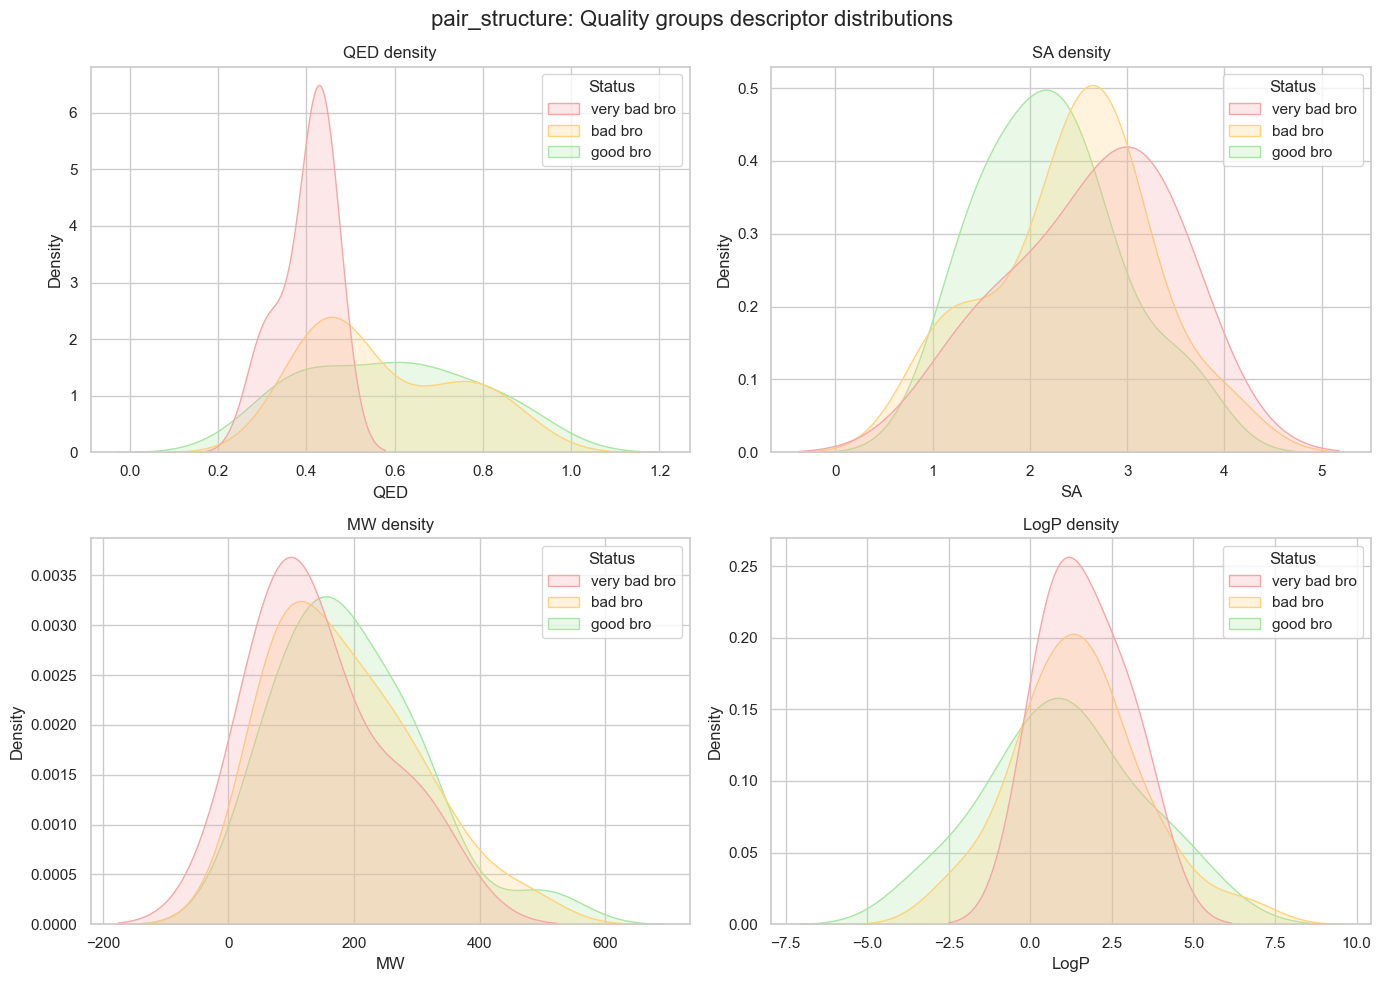

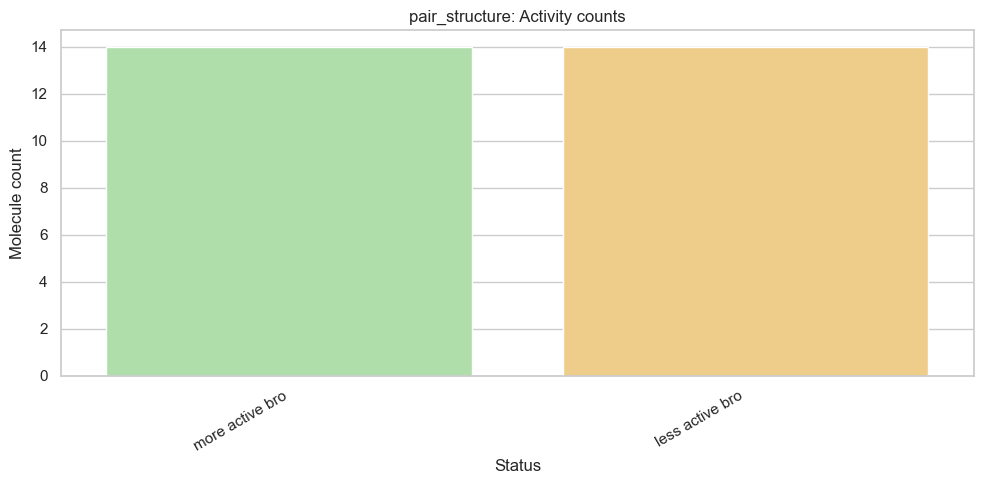

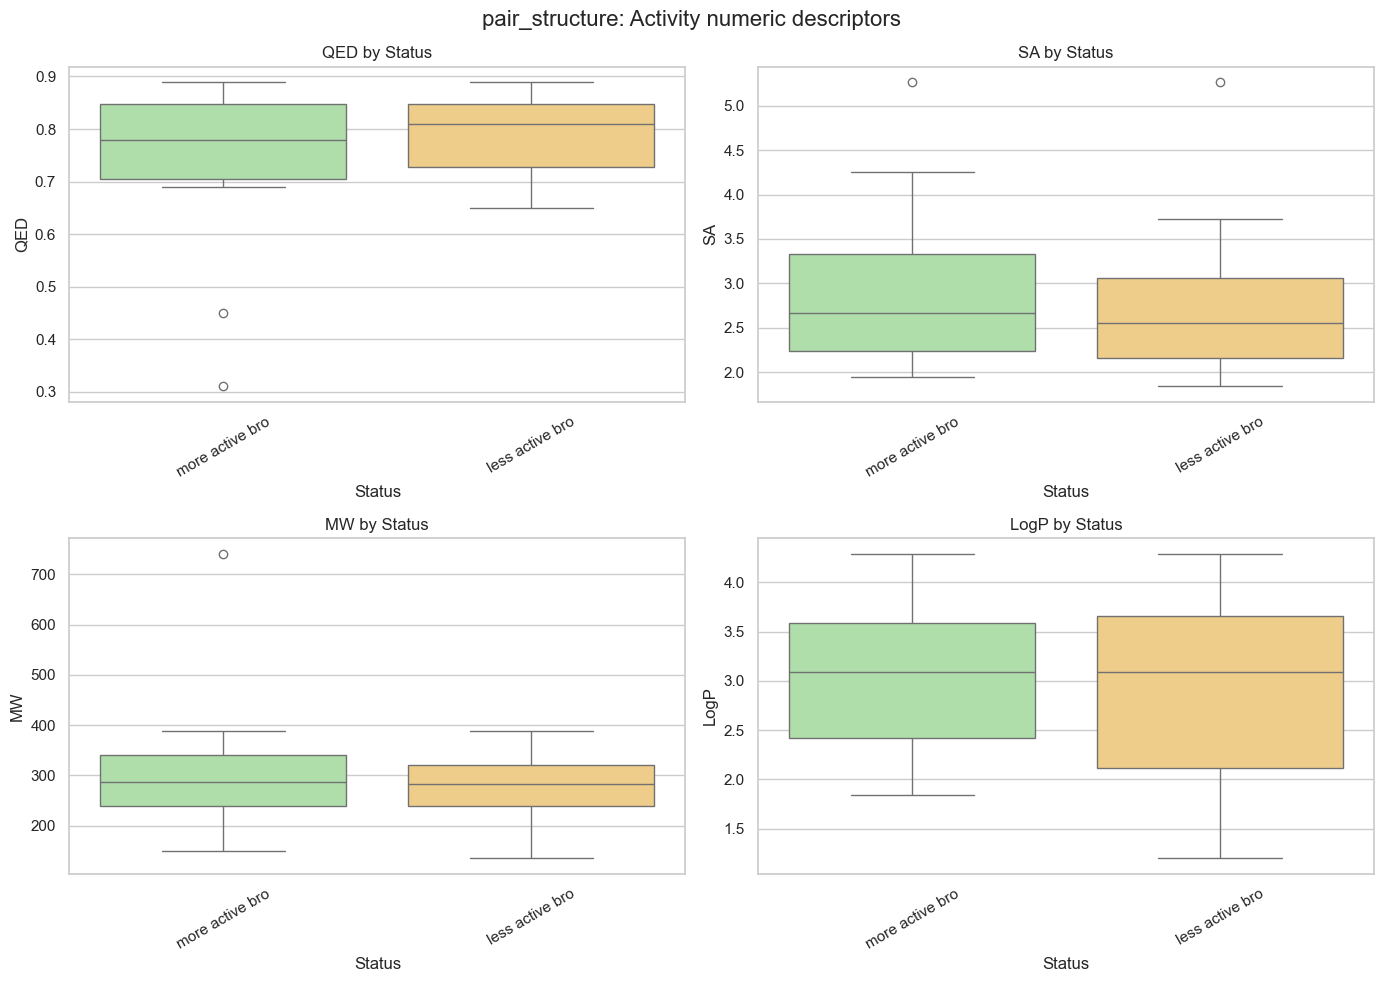

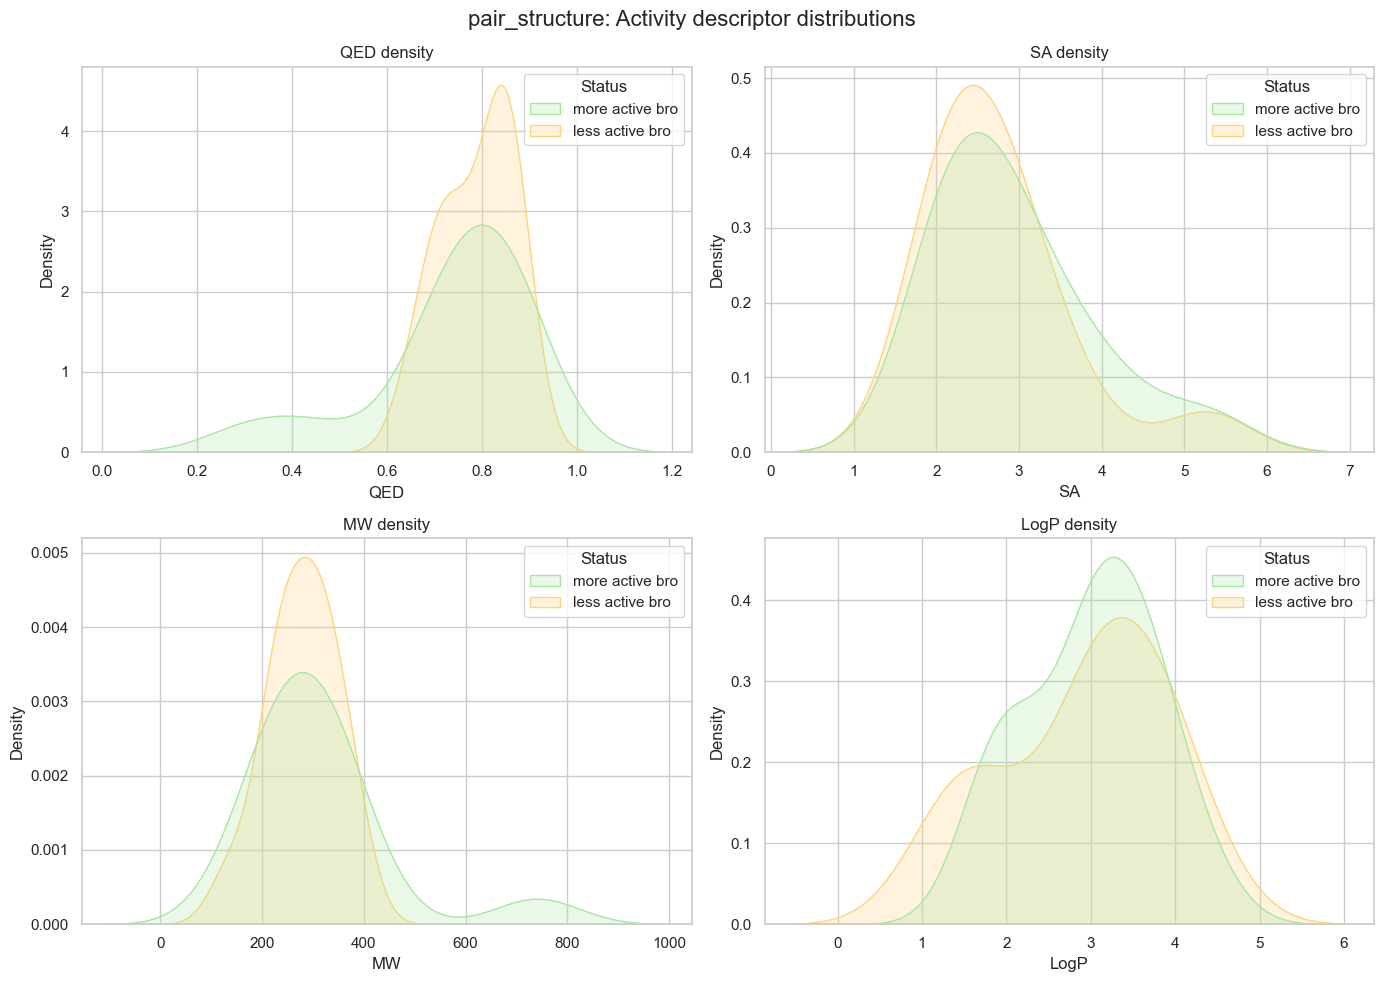

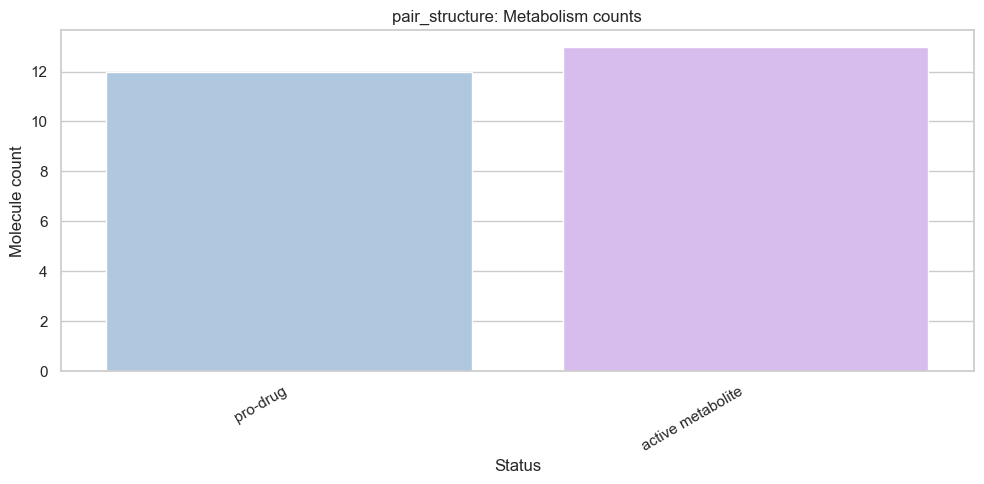

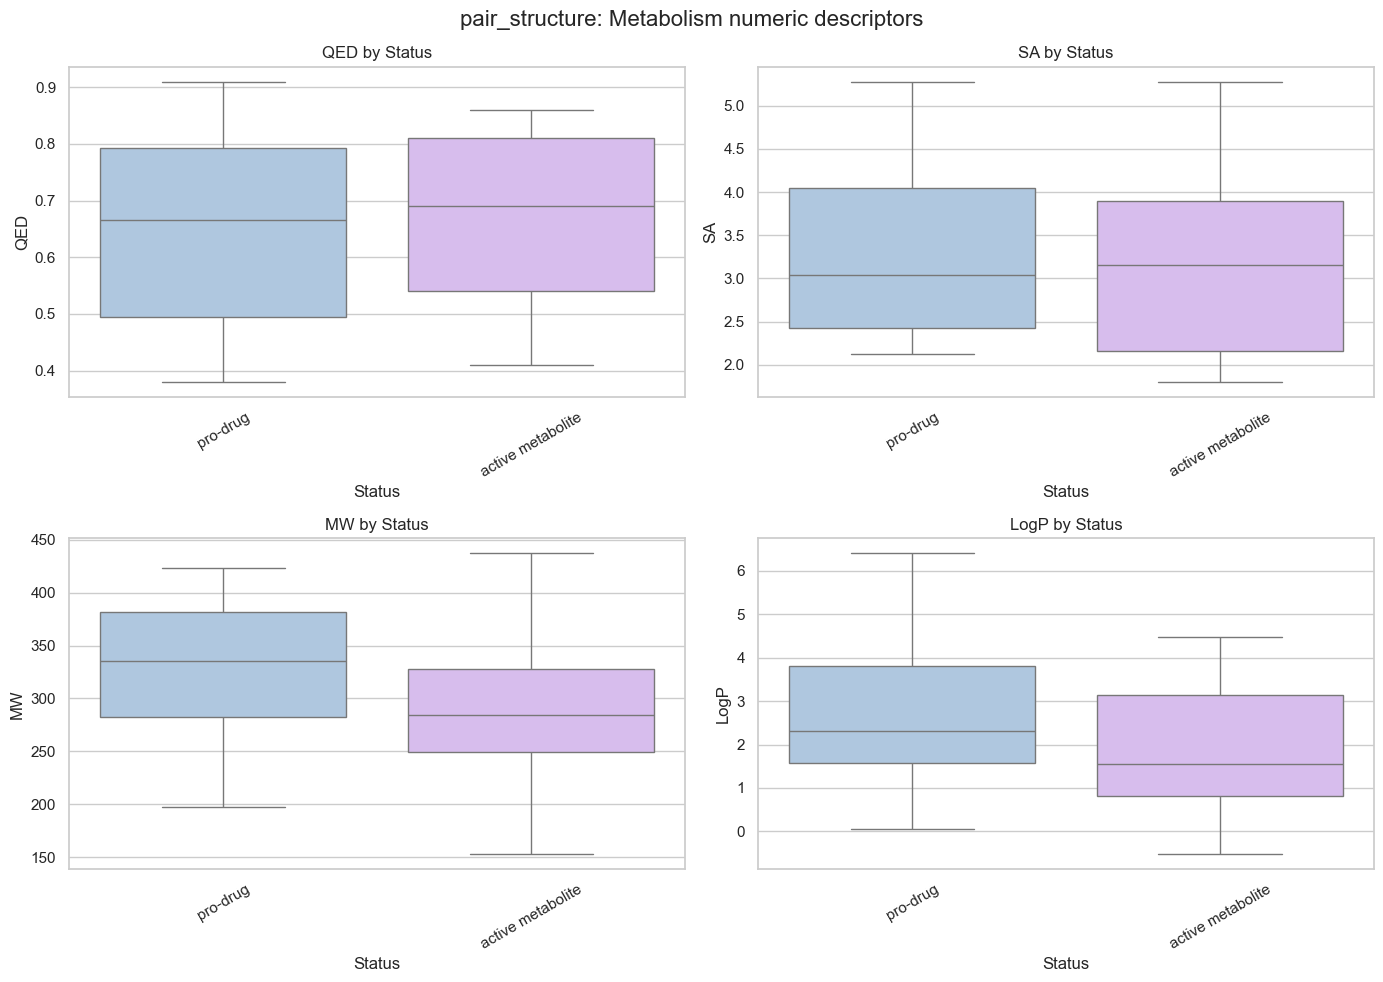

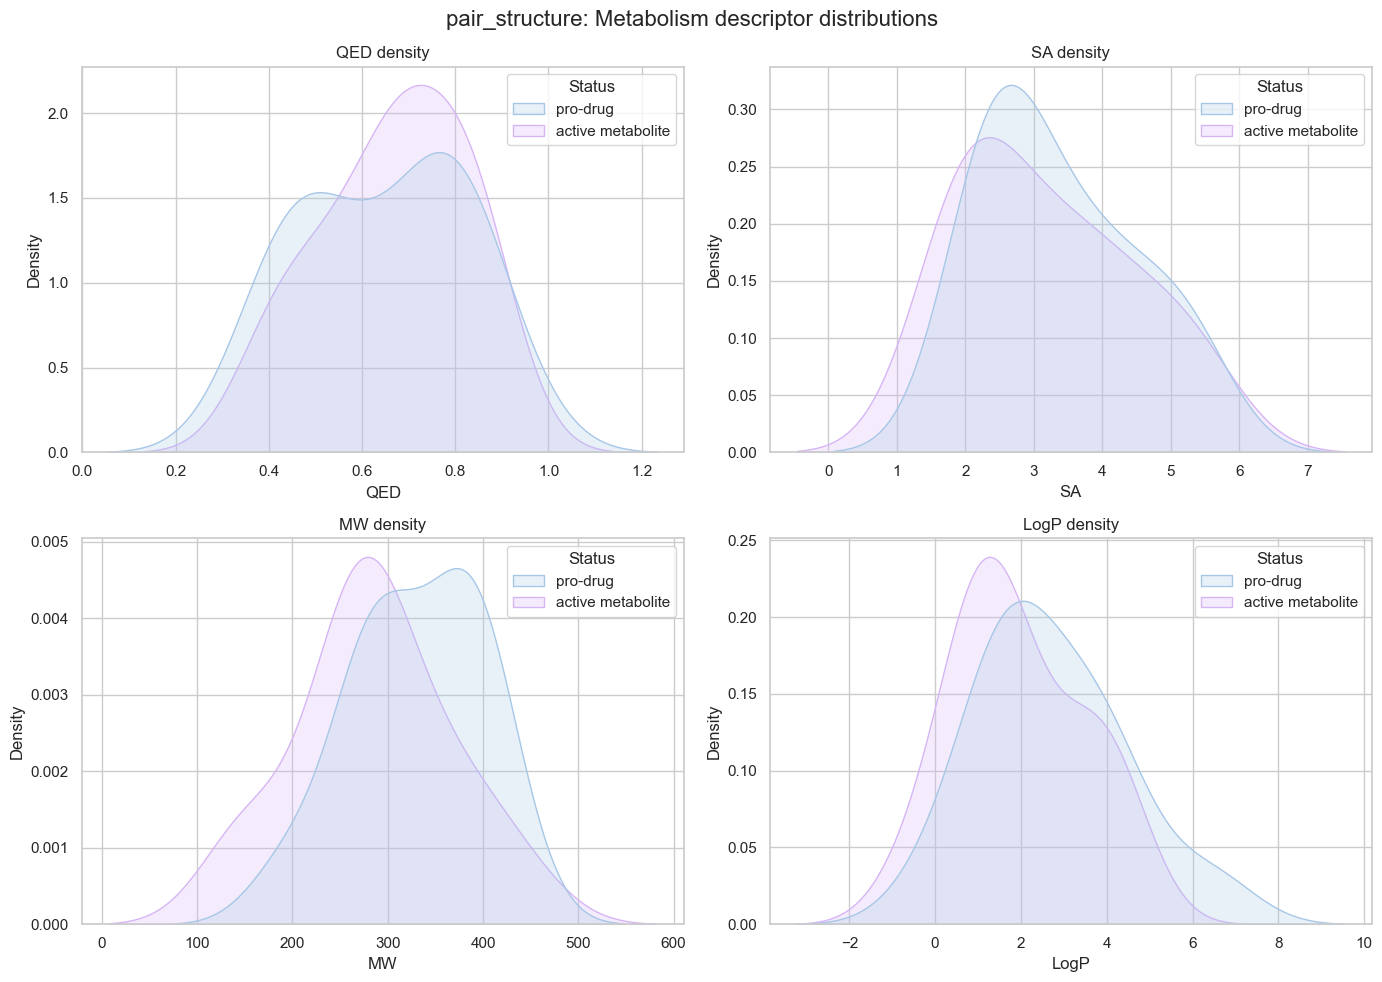

In [6]:
for dataset_name, config in DATASETS.items():
    df = loaded_data[dataset_name]
    for comparison in config.get("comparisons", []):
        category_col = comparison["category_col"]
        order = [value for value in comparison.get("order", []) if value in set(df[category_col].dropna())]
        if not order:
            continue

        comparison_df = df[df[category_col].isin(order)]
        title_prefix = f"{dataset_name}: {comparison['name']}"
        plot_category_counts(
            comparison_df,
            category_col=category_col,
            order=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} counts",
        )
        plot_numeric_boxplots(
            comparison_df,
            category_col=category_col,
            order=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} numeric descriptors",
        )
        plot_numeric_kdes(
            comparison_df,
            category_col=category_col,
            categories=order,
            palette=comparison.get("palette"),
            title=f"{title_prefix} descriptor distributions",
        )
